# Project Completion Local + Vertex Notebook

This notebook keeps the working path small: data-processing SQL is imported from `project_completion/data_processing.py`, the trainer can run locally from the notebook, and the same package can be submitted as a Vertex AI Custom Job. CI/CD files are unchanged. Environment values are read from shell variables or `.env`.

## Environment Setup

Run this once in a fresh local or Workbench environment.

In [1]:
INSTALL_DEPS = False  # Set True once, then restart the kernel

if INSTALL_DEPS:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements-local.txt"])

# Required before Vertex submit or GCS package upload:
#   gcloud auth application-default login
#   gcloud auth login
#   gcloud config set project $PROJECT_ID

import os
from pathlib import Path

env_candidates = [Path(".env"), Path("env"), Path("env.txt"), Path(".env.txt")]
env_file = next((path for path in env_candidates if path.exists()), None)

if env_file:
    print("Loading environment from:", env_file)
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
else:
    print("No env file found. Expected one of:", [str(path) for path in env_candidates])

required_env = ["PROJECT_ID", "REGION", "BUCKET"]
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    print("Missing env vars:", missing_env)
    print("Upload env.example or export these variables before running Vertex/GCS cells.")
else:
    print("Environment ready:", {name: os.getenv(name) for name in required_env})


Loading environment from: env.txt
Environment ready: {'PROJECT_ID': 'qwiklabs-asl-03-7c1aaee9a503', 'REGION': 'us-central1', 'BUCKET': 'qwiklabs-asl-03-7c1aaee9a503'}


In [2]:
import glob
import math
import os
import subprocess
from datetime import datetime

from project_completion.data_processing import (
    DataProcessingConfig,
    build_export_jobs,
    build_feature_sql,
    build_preview_query,
    build_split_sql,
)

## Configuration

In [3]:
from datetime import datetime
import sklearn


def get_gcloud_project(default="qwiklabs-asl-03-7c1aaee9a503"):
    try:
        value = subprocess.check_output(
            ["gcloud", "config", "get-value", "project"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip()
        return value or default
    except Exception:
        return default


PROJECT_ID = os.getenv("PROJECT_ID", get_gcloud_project())
REGION = os.getenv("REGION", "us-central1")
BUCKET = os.getenv("BUCKET", PROJECT_ID)
BUCKET_URI = f"gs://{BUCKET}"

config = DataProcessingConfig(
    project_id=PROJECT_ID,
    dataset_id=os.getenv("DATASET_ID", "jindong_lin"),
    table_id=os.getenv("TABLE_ID", "project_data"),
    bucket_uri=os.getenv("DATA_GCS_BASE_URI", f"{BUCKET_URI}/jindong_lin/data"),
)

TRAIN_DATA_PATH = f"{config.data_gcs_prefix}/train/project-train-*"
EVAL_DATA_PATH = f"{config.data_gcs_prefix}/valid/project-valid-*"
SCHEMA_PATH = os.getenv("SCHEMA_PATH", getattr(config, "schema_gcs_path", f"{config.data_gcs_prefix}/schema/feature_schema.json"))

# Use a fresh run directory by default so notebook analysis cannot accidentally
# read an old model.joblib created by another scikit-learn version.
if "LOCAL_RUN_ID" not in globals():
    LOCAL_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SKLEARN_TAG = sklearn.__version__.replace(".", "")
LOCAL_OUTPUT_DIR = (
    os.getenv("LOCAL_OUTPUT_DIR")
    or f"{BUCKET_URI}/project_completion/local_gbdt_sklearn{SKLEARN_TAG}_{LOCAL_RUN_ID}"
)

print("PROJECT_ID:", PROJECT_ID)
print("REGION:", REGION)
print("SOURCE_TABLE:", config.source_table)
print("TRAIN_DATA_PATH:", TRAIN_DATA_PATH)
print("EVAL_DATA_PATH:", EVAL_DATA_PATH)
print("SCHEMA_PATH:", SCHEMA_PATH)
print("Current scikit-learn:", sklearn.__version__)
print("LOCAL_OUTPUT_DIR:", LOCAL_OUTPUT_DIR)


PROJECT_ID: qwiklabs-asl-03-7c1aaee9a503
REGION: us-central1
SOURCE_TABLE: qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_dataform_features_mask_0615
TRAIN_DATA_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/train/project-train-*
EVAL_DATA_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/valid/project-valid-*
SCHEMA_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json
Current scikit-learn: 1.9.0
LOCAL_OUTPUT_DIR: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111402


## Data Processing Smoke Test

In [4]:
preview_query = build_preview_query(config.source_table)
feature_sql = build_feature_sql(config.source_table, config.feature_table)
split_sql = build_split_sql(config.feature_table, config.train_table, config.valid_table, config.test_table)
export_jobs = build_export_jobs(config)

assert f"FROM `{config.source_table}`" in preview_query
assert "SELECT *" in feature_sql
assert "days_to_S90 IS NOT NULL" in feature_sql
assert "days_to_S90 >= 0" in feature_sql
#assert "so_nr" in split_sql
#assert "projekt_id" in split_sql
#assert "FARM_FINGERPRINT" in split_sql
assert export_jobs[0][1].endswith("/train/project-train-*.csv")
assert export_jobs[1][1].endswith("/valid/project-valid-*.csv")
assert config.schema_gcs_path.endswith("/schema/feature_schema.json")

print("Data-processing helper smoke test passed.")


Data-processing helper smoke test passed.


## Optional Data Processing

Keep `RUN_DATA_PROCESSING = False` for normal training runs. Set it to `True` only for the first run or when the source BigQuery table has changed and the GCS CSV files must be regenerated.

In [5]:
RUN_DATA_PROCESSING = os.getenv("RUN_DATA_PROCESSING", "False").lower() == "true"

if RUN_DATA_PROCESSING:
    from google.cloud import bigquery, storage
    from project_completion.data_processing import export_tables_to_gcs, run_bigquery_data_processing

    bq_client = bigquery.Client(project=PROJECT_ID)
    storage_client = storage.Client(project=PROJECT_ID)
    bq_location = os.getenv("BQ_LOCATION")
    if not bq_location:
        dataset_ref = bigquery.DatasetReference(PROJECT_ID, config.dataset_id)
        bq_location = bq_client.get_dataset(dataset_ref).location

    row_counts = run_bigquery_data_processing(bq_client, config, location=bq_location)
    export_tables_to_gcs(
        bq_client,
        config,
        location=bq_location,
        storage_client=storage_client,
        clean_existing=True,
    )
    print("Regenerated CSV files from BigQuery.")
    print(row_counts)
else:
    print("Skip data processing. Reusing existing CSV files in GCS:")
    print("  train:", TRAIN_DATA_PATH)
    print("  valid:", EVAL_DATA_PATH)


Skip data processing. Reusing existing CSV files in GCS:
  train: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/train/project-train-*
  valid: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/valid/project-valid-*


In [6]:
os.getenv("LOCAL_EPOCHS")

## Run the trainer locally from the notebook

In [23]:
import sys
import subprocess
import json
import sklearn
import joblib
import tensorflow as tf
from datetime import datetime

print("Notebook Python:", sys.executable)
print("Notebook sklearn:", sklearn.__version__)
print("Notebook joblib:", joblib.__version__)

# Always train into a fresh local run directory. This prevents later cells from
# accidentally reading an older model.joblib created by a different environment.
LOCAL_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SKLEARN_TAG = sklearn.__version__.replace(".", "")
LOCAL_OUTPUT_DIR = f"{BUCKET_URI}/project_completion/local_gbdt_sklearn{SKLEARN_TAG}_{LOCAL_RUN_ID}"
ACTIVE_MODEL_DIR = LOCAL_OUTPUT_DIR.rstrip("/")
ACTIVE_MODEL_PATH = f"{ACTIVE_MODEL_DIR}/model.joblib"
print("Fresh LOCAL_OUTPUT_DIR:", LOCAL_OUTPUT_DIR)
print("Fresh ACTIVE_MODEL_PATH:", ACTIVE_MODEL_PATH)


def _env_int(name, default):
    return int(os.getenv(name, str(default)))


def _env_float(name, default):
    return float(os.getenv(name, str(default)))


N_ESTIMATORS = _env_int("N_ESTIMATORS", 500)
MAX_DEPTH = _env_int("MAX_DEPTH", 8)
GBDT_LEARNING_RATE = _env_float("GBDT_LEARNING_RATE", 0.1)
RANDOM_STATE = _env_int("RANDOM_STATE", 42)
LABEL_SCALE = _env_float("LABEL_SCALE", 1.0)

print("GBDT n_estimators:", N_ESTIMATORS)
print("GBDT max_depth:", MAX_DEPTH)
print("GBDT learning_rate:", GBDT_LEARNING_RATE)
print("Schema path:", SCHEMA_PATH)

local_train_cmd = [
    sys.executable, "-m", "trainer.task",
    "--train_data_path", TRAIN_DATA_PATH,
    "--eval_data_path", EVAL_DATA_PATH,
    "--schema_path", SCHEMA_PATH,
    "--output_dir", LOCAL_OUTPUT_DIR,
    "--n_estimators", str(N_ESTIMATORS),
    "--max_depth", str(MAX_DEPTH),
    "--learning_rate", str(GBDT_LEARNING_RATE),
    "--random_state", str(RANDOM_STATE),
    "--label_scale", str(LABEL_SCALE),
]

env = os.environ.copy()
env.setdefault("CUDA_VISIBLE_DEVICES", "-1")
env.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

# Verify the child process uses the same Python and dependency versions as this notebook.
version_check_cmd = [
    sys.executable,
    "-c",
    "import sys, sklearn, joblib; print('Training Python:', sys.executable); print('Training sklearn:', sklearn.__version__); print('Training joblib:', joblib.__version__)",
]
subprocess.run(version_check_cmd, cwd="project_completion", env=env, check=True)

print("Training command:", local_train_cmd)
subprocess.run(local_train_cmd, cwd="project_completion", env=env, check=True)

# Immediately validate the newly written metadata before any later cell tries to load the model.
metadata_path = f"{ACTIVE_MODEL_DIR}/model_metadata.json"
print("Metadata path:", metadata_path)
with tf.io.gfile.GFile(metadata_path, "r") as f:
    model_metadata = json.load(f)

model_versions = model_metadata["dependency_versions"]
print("Model dependency versions:", model_versions)

if model_versions.get("scikit_learn_version") != sklearn.__version__:
    raise RuntimeError(
        f"Training sklearn mismatch: model={model_versions.get('scikit_learn_version')} "
        f"notebook={sklearn.__version__}. Do not use this model."
    )
if model_versions.get("joblib_version") != joblib.__version__:
    raise RuntimeError(
        f"Training joblib mismatch: model={model_versions.get('joblib_version')} "
        f"notebook={joblib.__version__}. Do not use this model."
    )

print("Ready for analysis with ACTIVE_MODEL_PATH:", ACTIVE_MODEL_PATH)


Notebook Python: /opt/micromamba/envs/jupyterlab/bin/python3
Notebook sklearn: 1.9.0
Notebook joblib: 1.5.3
Fresh LOCAL_OUTPUT_DIR: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805
Fresh ACTIVE_MODEL_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/model.joblib
GBDT n_estimators: 100
GBDT max_depth: 5
GBDT learning_rate: 0.05
Schema path: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json
Training Python: /opt/micromamba/envs/jupyterlab/bin/python3
Training sklearn: 1.9.0
Training joblib: 1.5.3
Training command: ['/opt/micromamba/envs/jupyterlab/bin/python3', '-m', 'trainer.task', '--train_data_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/train/project-train-*', '--eval_data_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/valid/project-valid-*', '--schema_path', 'gs://qwiklabs-asl-03-7c1aae

2026-06-17 11:18:09.163229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-17 11:18:09.189688: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-17 11:18:09.197993: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


{
  "dependency_versions": {
    "joblib_version": "1.5.3",
    "numpy_version": "1.26.4",
    "pandas_version": "3.0.3",
    "python_version": "3.12.13",
    "scikit_learn_version": "1.9.0",
    "tensorflow_version": "2.17.1"
  },
  "eval_loss_mse": 4768.720334746026,
  "eval_mae_days": 40.27992262112358,
  "eval_r2": 0.9781175192958811,
  "eval_rmse_days": 69.05592179347131,
  "eval_rows": 8397,
  "feature_importance_by_original_feature_path": "gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/feature_importance_by_original_feature.csv",
  "feature_importance_encoded_path": "gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/feature_importance_encoded.csv",
  "feature_schema": {
    "categorical_features": [
      "zustaendige_region",
      "ziel_des_projekts",
      "area_gu",
      "dim_squads_mac"
    ],
    "csv_columns": [
      "so_nr",
      "projekt_id",
      "zustaendige_region",
      "ziel_d

## View Local Training with TensorBoard

Run this cell after local training finishes to inspect TensorBoard logs written under `LOCAL_OUTPUT_DIR/tensorboard`.


In [24]:
# TensorBoard for the local trainer output.
# If the extension is already loaded, Jupyter may print a harmless message.
#!kill 28504
%load_ext tensorboard

TENSORBOARD_LOGDIR = f"{LOCAL_OUTPUT_DIR.rstrip('/')}/tensorboard"
print("TensorBoard logdir:", TENSORBOARD_LOGDIR)
%tensorboard --logdir {TENSORBOARD_LOGDIR} --port 8000


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
TensorBoard logdir: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/tensorboard


ERROR: Failed to launch TensorBoard (exited with 255).
Contents of stderr:
2026-06-17 11:19:32.364157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-17 11:19:32.389358: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-17 11:19:32.396500: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

E0617 11:19:35.595240 140433562699584 program.py:300] TensorBoard could not bind to port 8000, i

## Submit Custom Job using the Vertex AI SDK

This section creates or reuses a Vertex AI TensorBoard instance by default, gets the compute service account with `gcloud`, and submits the Custom Job with both `service_account` and `tensorboard`.


In [25]:
from pathlib import Path
import os
import subprocess
import sys

RUN_VERTEX_CUSTOM_JOB = os.getenv("RUN_VERTEX_CUSTOM_JOB", "True").lower() == "true"

cmd = [sys.executable, "scripts/submit_training_job.py", "--env_file", "env.txt"]
if not RUN_VERTEX_CUSTOM_JOB:
    cmd.append("--no_submit")

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)


Running: /opt/micromamba/envs/jupyterlab/bin/python3 scripts/submit_training_job.py --env_file env.txt --no_submit
running sdist
running egg_info
writing project_completion_trainer.egg-info/PKG-INFO
writing dependency_links to project_completion_trainer.egg-info/dependency_links.txt
writing requirements to project_completion_trainer.egg-info/requires.txt
writing top-level names to project_completion_trainer.egg-info/top_level.txt
reading manifest file 'project_completion_trainer.egg-info/SOURCES.txt'
writing manifest file 'project_completion_trainer.egg-info/SOURCES.txt'
running check
creating project_completion_trainer-0.1
creating project_completion_trainer-0.1/project_completion_trainer.egg-info
creating project_completion_trainer-0.1/trainer
copying files to project_completion_trainer-0.1...
copying setup.py -> project_completion_trainer-0.1
copying project_completion_trainer.egg-info/PKG-INFO -> project_completion_trainer-0.1/project_completion_trainer.egg-info
copying project_com


Copying file://project_completion/dist/project_completion_trainer-0.1.tar.gz to gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/packages/project_completion_trainer_20260617_111939.tar.gz
  
.


Local package: project_completion/dist/project_completion_trainer-0.1.tar.gz
PACKAGE_URI: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/packages/project_completion_trainer_20260617_111939.tar.gz
MODEL_OUTPUT_DIR: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/trained_gbdt_model_20260617_111939
TensorBoard: projects/192763454488/locations/us-central1/tensorboards/6279198756042702848
Service account: 192763454488-compute@developer.gserviceaccount.com
Training args: ['--train_data_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/train/project-train-*.csv', '--eval_data_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/valid/project-valid-*.csv', '--schema_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json', '--output_dir', 'gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/trained_gbdt_model_20260617_111939', '--n_estimators', '100', '--max_depth', '5', '--learnin

CompletedProcess(args=['/opt/micromamba/envs/jupyterlab/bin/python3', 'scripts/submit_training_job.py', '--env_file', 'env.txt', '--no_submit'], returncode=0)

## Running analysis and predict



In [26]:
import json
import sklearn
import joblib
import tensorflow as tf

from project_completion.trainer import model as trainer_model

# Prefer the model produced by the local training cell. Set VERTEX_MODEL_DIR only
# when you intentionally want to analyze a Vertex training output directory.
VERTEX_MODEL_DIR = os.getenv("VERTEX_MODEL_DIR")
if VERTEX_MODEL_DIR:
    ACTIVE_MODEL_DIR = VERTEX_MODEL_DIR.rstrip("/")
elif "ACTIVE_MODEL_DIR" not in globals():
    ACTIVE_MODEL_DIR = LOCAL_OUTPUT_DIR.rstrip("/")

ACTIVE_MODEL_PATH = f"{ACTIVE_MODEL_DIR}/model.joblib"
ACTIVE_METADATA_PATH = f"{ACTIVE_MODEL_DIR}/model_metadata.json"

print("Using GBDT model:", ACTIVE_MODEL_PATH)
print("Expected metadata:", ACTIVE_METADATA_PATH)

with tf.io.gfile.GFile(ACTIVE_METADATA_PATH, "r") as f:
    active_model_metadata = json.load(f)

print("Model dependency versions:", active_model_metadata["dependency_versions"])
trainer_model.assert_model_dependency_compatible(ACTIVE_MODEL_PATH)
print("Model dependency check passed.")


Using GBDT model: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/model.joblib
Expected metadata: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/model_metadata.json
Model dependency versions: {'joblib_version': '1.5.3', 'numpy_version': '1.26.4', 'pandas_version': '3.0.3', 'python_version': '3.12.13', 'scikit_learn_version': '1.9.0', 'tensorflow_version': '2.17.1'}
Model dependency check passed.


In [27]:
import sklearn
print(sklearn.__version__)

1.9.0


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import r2_score

from project_completion.trainer import model as trainer_model

schema = trainer_model.load_feature_schema(SCHEMA_PATH)
model_path = ACTIVE_MODEL_PATH
print("Loading model from:", model_path)
trained_model = trainer_model.load_joblib_gcs_compatible(model_path)

TEST_DATA_PATH = f"{config.data_gcs_prefix}/test/project-test-*"
test_df = trainer_model.read_csv_dataset(TEST_DATA_PATH, schema)
x_test, y_test = trainer_model.split_features_label(test_df, schema, label_scale=LABEL_SCALE)
y_pred = trained_model.predict(x_test)

pred_df = pd.DataFrame({
    "actual_days_to_S90": y_test * LABEL_SCALE,
    "predicted_days_to_S90": y_pred * LABEL_SCALE,
})
pred_df["error_days"] = pred_df["predicted_days_to_S90"] - pred_df["actual_days_to_S90"]

mae = np.mean(np.abs(pred_df["error_days"]))
rmse = np.sqrt(np.mean(np.square(pred_df["error_days"])))
r2 = r2_score(pred_df["actual_days_to_S90"], pred_df["predicted_days_to_S90"])

print(f"Rows: {len(pred_df):,}")
print(f"MAE days: {mae:.2f}")
print(f"RMSE days: {rmse:.2f}")
print(f"R2: {r2:.4f}")

pred_df.head()


Loading model from: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/model.joblib
Rows: 3,619
MAE days: 49.65
RMSE days: 90.82
R2: 0.9589


,actual_days_to_S90,predicted_days_to_S90,error_days
0,22.0,70.811011,48.811011
1,58.0,91.256938,33.256938
2,261.0,275.973745,14.973745
3,261.0,275.973745,14.973745
4,261.0,275.973745,14.973745


In [29]:
# Feature importance by original input feature

import pandas as pd
import tensorflow as tf

model_output_dir = ACTIVE_MODEL_DIR
feature_importance_path = f"{model_output_dir}/feature_importance_by_original_feature.csv"
print("Feature importance path:", feature_importance_path)

if tf.io.gfile.exists(feature_importance_path):
    with tf.io.gfile.GFile(feature_importance_path, "r") as f:
        feature_importance_df = pd.read_csv(f)
else:
    preprocess = trained_model.named_steps["preprocess"]
    regressor = trained_model.named_steps["model"]
    encoded_importance_df = pd.DataFrame({
        "encoded_feature": preprocess.get_feature_names_out(),
        "importance": regressor.feature_importances_,
    })

    def original_feature_name(encoded_name):
        name = encoded_name.split("__", 1)[-1]
        for feature_name in sorted(schema["categorical_features"], key=len, reverse=True):
            if name == feature_name or name.startswith(f"{feature_name}_"):
                return feature_name
        for feature_name in schema["numeric_features"]:
            if name == feature_name:
                return feature_name
        return name

    encoded_importance_df["original_feature"] = encoded_importance_df["encoded_feature"].map(original_feature_name)
    feature_importance_df = (
        encoded_importance_df.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

feature_importance_df.head(20)


Feature importance path: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/feature_importance_by_original_feature.csv


,original_feature,importance
0,days_stx71_from_stx30,0.829244
1,days_stx51a_from_stx30,0.157171
2,days_stx68_from_stx30,0.004595
3,ziel_des_projekts,0.004216
4,days_stx56a_from_stx30,0.001634
5,days_stx44_from_stx30,0.001388
6,dim_squads_mac,0.000700
7,zustaendige_region,0.000327
8,days_stx52_from_stx30,0.000185
9,area_gu,0.000146


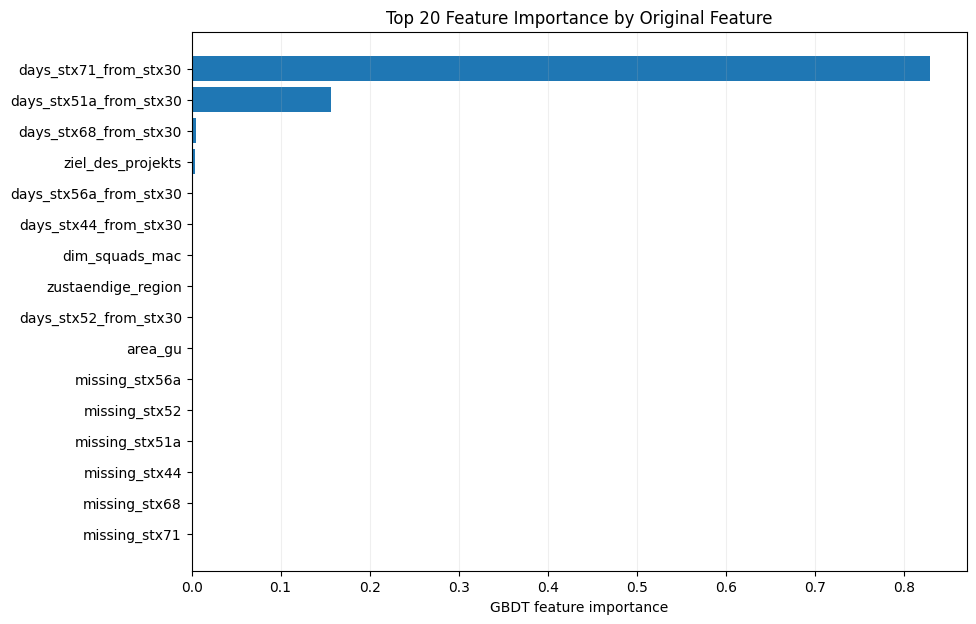

In [30]:
# Plot top feature importance

top_n = 20
plot_df = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["original_feature"], plot_df["importance"])
plt.xlabel("GBDT feature importance")
plt.title(f"Top {top_n} Feature Importance by Original Feature")
plt.grid(axis="x", alpha=0.2)
plt.show()


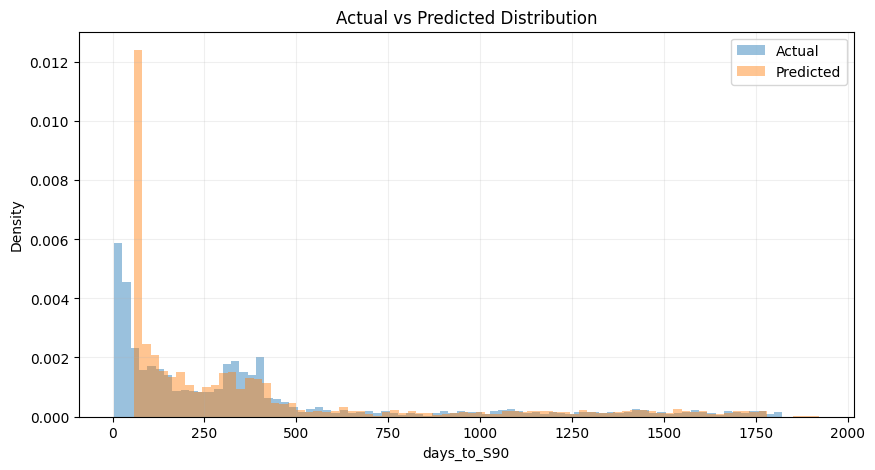

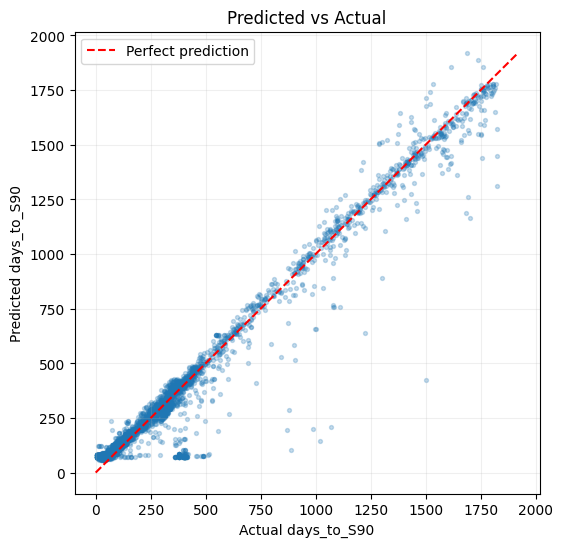

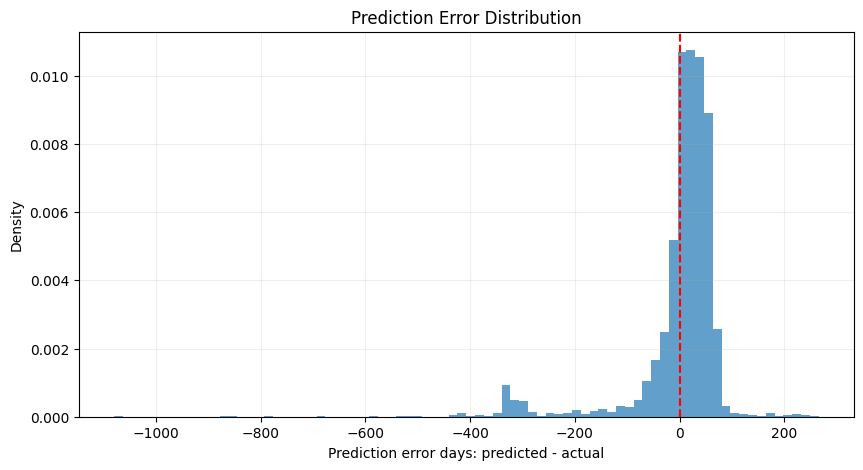

In [31]:
# 1. Actual vs predicted distribution
plt.figure(figsize=(10, 5))
plt.hist(pred_df["actual_days_to_S90"], bins=80, density=True, alpha=0.45, label="Actual")
plt.hist(pred_df["predicted_days_to_S90"], bins=80, density=True, alpha=0.45, label="Predicted")
plt.xlabel("days_to_S90")
plt.ylabel("Density")
plt.title("Actual vs Predicted Distribution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 2. Predicted vs actual scatter
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["actual_days_to_S90"], pred_df["predicted_days_to_S90"], alpha=0.25, s=8)
max_v = max(pred_df["actual_days_to_S90"].max(), pred_df["predicted_days_to_S90"].max())
plt.plot([0, max_v], [0, max_v], "r--", label="Perfect prediction")
plt.xlabel("Actual days_to_S90")
plt.ylabel("Predicted days_to_S90")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 3. Error distribution
plt.figure(figsize=(10, 5))
plt.hist(pred_df["error_days"], bins=80, density=True, alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction error days: predicted - actual")
plt.ylabel("Density")
plt.title("Prediction Error Distribution")
plt.grid(alpha=0.2)
plt.show()


In [32]:
predictions_dir = f"{ACTIVE_MODEL_DIR}/predictions"
predictions_path = f"{predictions_dir}/test_predictions.csv"
tf.io.gfile.makedirs(predictions_dir)

with tf.io.gfile.GFile(predictions_path, "w") as f:
    pred_df.to_csv(f, index=False)

print("Saved predictions to:", predictions_path)


Saved predictions to: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/predictions/test_predictions.csv


In [33]:
from google.cloud import bigquery
import numpy as np
import pandas as pd

from project_completion.trainer import model as trainer_model

schema = trainer_model.load_feature_schema(SCHEMA_PATH)
model_path = ACTIVE_MODEL_PATH
print("Loading model from:", model_path)
trained_model = trainer_model.load_joblib_gcs_compatible(model_path)

bq_client = bigquery.Client(project=PROJECT_ID)

SCORING_TABLE = "qwiklabs-asl-03-7c1aaee9a503.jindong_lin.frozenlist-2026-forecast"

input_columns = schema["categorical_features"] + schema["numeric_features"]
meta_columns = [
    "so_nr",
    "projekt_id",
    "ist_stx30",
    "ist_stx90",
]

select_columns = meta_columns + input_columns
select_sql = ",".join([f"`{c}`" for c in select_columns])

score_sql = f"""
SELECT
  {select_sql}
FROM `{SCORING_TABLE}`
WHERE ist_stx30 IS NOT NULL
"""

score_df = bq_client.query(score_sql).to_dataframe()
print("Rows to predict:", len(score_df))
score_df.head()


Loading model from: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_gbdt_sklearn190_20260617_111805/model.joblib


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Rows to predict: 8349


,so_nr,projekt_id,ist_stx30,ist_stx90,zustaendige_region,ziel_des_projekts,area_gu,dim_squads_mac,missing_stx44,days_stx44_from_stx30,missing_stx51a,days_stx51a_from_stx30,missing_stx52,days_stx52_from_stx30,missing_stx56a,days_stx56a_from_stx30,missing_stx68,days_stx68_from_stx30,missing_stx71,days_stx71_from_stx30
0,124992506,700961697,2021-02-11,NaT,R1,Z19,A7,S1,0,90,0,1764,0,1386,0,1701,1,-1,1,-1
1,125991509,700961617,2021-02-11,NaT,R1,Z19,A7,S1,0,273,0,1885,0,264,0,1645,1,-1,1,-1
2,128990077,700965639,2021-03-16,NaT,R1,Z18,A7,S1,0,10,1,-1,0,352,1,-1,1,-1,1,-1
3,127990162,700965295,2021-05-06,2026-03-19,R1,Z18,A7,S1,0,19,0,1596,0,439,0,1398,1,-1,0,1814
4,128990437,700965776,2021-05-06,NaT,R1,Z18,A7,S1,0,209,1,-1,0,168,1,-1,1,-1,1,-1


In [34]:
score_features = score_df[input_columns].copy()
for col in schema["categorical_features"]:
    score_features[col] = score_features[col].fillna("UNKNOWN").astype(str)
for col in schema["numeric_features"]:
    score_features[col] = pd.to_numeric(score_features[col], errors="coerce")

predicted_days = trained_model.predict(score_features) * LABEL_SCALE

prediction_df = score_df[meta_columns].copy()
prediction_df["predicted_days_to_S90"] = predicted_days
prediction_df["predicted_months_to_S90"] = prediction_df["predicted_days_to_S90"] / 30.4375
prediction_df["predicted_quarters_to_S90"] = prediction_df["predicted_days_to_S90"] / 91.3125

prediction_df["ist_stx30"] = pd.to_datetime(prediction_df["ist_stx30"])
prediction_df["ist_stx90"] = pd.to_datetime(prediction_df["ist_stx90"])

prediction_df["predicted_s90_date"] = prediction_df["ist_stx30"] + pd.to_timedelta(
    prediction_df["predicted_days_to_S90"].round().astype(int),
    unit="D",
)

prediction_df["predicted_s90_month"] = prediction_df["predicted_s90_date"].dt.to_period("M").astype("string")
prediction_df["predicted_s90_quarter"] = prediction_df["predicted_s90_date"].dt.to_period("Q").astype("string")

# Keep missing actual dates as <NA>, instead of converting NaT into the string "NaT".
prediction_df["actual_s90_month"] = prediction_df["ist_stx90"].dt.to_period("M").astype("string")
prediction_df["actual_s90_quarter"] = prediction_df["ist_stx90"].dt.to_period("Q").astype("string")

prediction_df.head(20)


,so_nr,projekt_id,ist_stx30,ist_stx90,predicted_days_to_S90,predicted_months_to_S90,predicted_quarters_to_S90,predicted_s90_date,predicted_s90_month,predicted_s90_quarter,actual_s90_month,actual_s90_quarter
0,124992506,700961697,2021-02-11,NaT,1636.132253,53.753832,17.917944,2025-08-05,2025-08,2025Q3,<NA>,<NA>
1,125991509,700961617,2021-02-11,NaT,1647.232143,54.118510,18.039503,2025-08-16,2025-08,2025Q3,<NA>,<NA>
2,128990077,700965639,2021-03-16,NaT,344.357112,11.313581,3.771194,2022-02-23,2022-02,2022Q1,<NA>,<NA>
3,127990162,700965295,2021-05-06,2026-03-19,1715.175866,56.350747,18.783582,2026-01-15,2026-01,2026Q1,2026-03,2026Q1
4,128990437,700965776,2021-05-06,NaT,349.319351,11.476611,3.825537,2022-04-20,2022-04,2022Q2,<NA>,<NA>
5,128990240,700965657,2021-05-11,NaT,344.357112,11.313581,3.771194,2022-04-20,2022-04,2022Q2,<NA>,<NA>
6,124992218,700961176,2021-06-08,2026-06-05,1571.356359,51.625671,17.208557,2025-09-26,2025-09,2025Q3,2026-06,2026Q2
7,128992387,700965734,2021-06-11,NaT,340.768580,11.195682,3.731894,2022-05-18,2022-05,2022Q2,<NA>,<NA>
8,127991823,701088207,2021-06-14,NaT,1873.474078,61.551510,20.517170,2026-07-31,2026-07,2026Q3,<NA>,<NA>
9,125991589,701097348,2021-07-06,NaT,377.102525,12.389405,4.129802,2022-07-18,2022-07,2022Q3,<NA>,<NA>


In [35]:
completed_df = prediction_df[prediction_df["ist_stx90"].notna()].copy()

completed_df["actual_days_to_S90"] = (
    completed_df["ist_stx90"] - completed_df["ist_stx30"]
).dt.days

completed_df["error_days"] = completed_df["predicted_days_to_S90"] - completed_df["actual_days_to_S90"]

completed_summary = pd.DataFrame({
    "metric": ["mae_days", "rmse_days", "r2", "bias_days"],
    "value": [
        np.mean(np.abs(completed_df["error_days"])),
        np.sqrt(np.mean(np.square(completed_df["error_days"]))),
        r2_score(completed_df["actual_days_to_S90"], completed_df["predicted_days_to_S90"]),
        np.mean(completed_df["error_days"]),
    ],
})

completed_summary

,metric,value
0,mae_days,62.297913
1,rmse_days,114.321018
2,r2,0.952535
3,bias_days,19.141298


In [36]:
# Month/quarter accuracy directly from prediction_df, no BigQuery output table needed.
actual_exists = (
    prediction_df["actual_s90_month"].notna()
    & prediction_df["actual_s90_quarter"].notna()
)

prediction_eval_df = prediction_df.loc[actual_exists].copy()

same_month = prediction_eval_df["predicted_s90_month"].eq(prediction_eval_df["actual_s90_month"])
same_quarter = prediction_eval_df["predicted_s90_quarter"].eq(prediction_eval_df["actual_s90_quarter"])

month_quarter_accuracy_df = pd.DataFrame({
    "metric": [
        "rows_with_actual",
        "same_month_count",
        "same_month_rate",
        "same_quarter_count",
        "same_quarter_rate",
        "same_both_count",
        "same_both_rate",
    ],
    "value": [
        len(prediction_eval_df),
        int(same_month.sum()),
        same_month.mean() if len(prediction_eval_df) else np.nan,
        int(same_quarter.sum()),
        same_quarter.mean() if len(prediction_eval_df) else np.nan,
        int((same_month & same_quarter).sum()),
        (same_month & same_quarter).mean() if len(prediction_eval_df) else np.nan,
    ],
})

month_quarter_accuracy_df


,metric,value
0,rows_with_actual,2809.000000
1,same_month_count,773.000000
2,same_month_rate,0.275187
3,same_quarter_count,1521.000000
4,same_quarter_rate,0.541474
5,same_both_count,773.000000
6,same_both_rate,0.275187


In [37]:
month_quarter_accuracy_display_df = month_quarter_accuracy_df.copy()
rate_mask = month_quarter_accuracy_display_df["metric"].str.endswith("_rate")
month_quarter_accuracy_display_df.loc[rate_mask, "value"] = (
    month_quarter_accuracy_display_df.loc[rate_mask, "value"].astype(float).mul(100).round(2).astype(str) + "%"
)

month_quarter_accuracy_display_df


TypeError: Invalid value '<ArrowStringArray>
['27.52%', '54.15%', '27.52%']
Length: 3, dtype: str' for dtype 'float64'

In [38]:
# Where month/quarter predictions differ from actual values.
month_quarter_error_detail_df = (
    prediction_eval_df
    .groupby(
        [
            "predicted_s90_month",
            "actual_s90_month",
            "predicted_s90_quarter",
            "actual_s90_quarter",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

month_quarter_error_detail_df.head(50)


,predicted_s90_month,actual_s90_month,predicted_s90_quarter,actual_s90_quarter,row_count
94,2026-04,2026-03,2026Q2,2026Q1,182
88,2026-03,2026-03,2026Q1,2026Q1,182
81,2026-02,2026-02,2026Q1,2026Q1,165
102,2026-05,2026-05,2026Q2,2026Q2,162
113,2026-07,2026-05,2026Q3,2026Q2,161
87,2026-03,2026-02,2026Q1,2026Q1,143
107,2026-06,2026-05,2026Q2,2026Q2,135
114,2026-07,2026-06,2026Q3,2026Q2,121
95,2026-04,2026-04,2026Q2,2026Q2,119
101,2026-05,2026-04,2026Q2,2026Q2,112


In [39]:
# Optional: inspect only rows where either month or quarter is wrong.
month_quarter_mismatch_df = prediction_eval_df.loc[
    ~(
        prediction_eval_df["predicted_s90_month"].eq(prediction_eval_df["actual_s90_month"])
        & prediction_eval_df["predicted_s90_quarter"].eq(prediction_eval_df["actual_s90_quarter"])
    )
].copy()

month_quarter_mismatch_df[
    [
        "so_nr",
        "projekt_id",
        "ist_stx30",
        "ist_stx90",
        "predicted_s90_date",
        "predicted_s90_month",
        "actual_s90_month",
        "predicted_s90_quarter",
        "actual_s90_quarter",
        "predicted_days_to_S90",
    ]
].head(50)


,so_nr,projekt_id,ist_stx30,ist_stx90,predicted_s90_date,predicted_s90_month,actual_s90_month,predicted_s90_quarter,actual_s90_quarter,predicted_days_to_S90
3,127990162,700965295,2021-05-06,2026-03-19,2026-01-15,2026-01,2026-03,2026Q1,2026Q1,1715.175866
6,124992218,700961176,2021-06-08,2026-06-05,2025-09-26,2025-09,2026-06,2025Q3,2026Q2,1571.356359
10,121991634,700965425,2021-10-06,2026-03-31,2026-05-06,2026-05,2026-03,2026Q2,2026Q1,1672.907277
14,125991612,701143826,2021-10-20,2026-03-25,2025-10-02,2025-10,2026-03,2025Q4,2026Q1,1443.303824
20,124992570,701150563,2021-11-24,2026-03-06,2025-09-28,2025-09,2026-03,2025Q3,2026Q1,1403.755630
21,127991853,701148169,2021-11-26,2026-04-27,2025-10-08,2025-10,2026-04,2025Q4,2026Q2,1411.857270
24,127991877,701175837,2022-03-24,2026-03-23,2026-02-24,2026-02,2026-03,2026Q1,2026Q1,1433.441209
25,125991644,701175485,2022-03-29,2026-03-16,2026-04-01,2026-04,2026-03,2026Q2,2026Q1,1463.592840
26,127991876,701175794,2022-03-29,2026-03-26,2026-04-02,2026-04,2026-03,2026Q2,2026Q1,1465.021819
27,125991655,701178484,2022-04-07,2026-03-24,2025-11-17,2025-11,2026-03,2025Q4,2026Q1,1319.851202
